# Smart Fund Advisor — Notebook 1: EDA & Feature Engineering

**Objective:** 
Explore the bank user dataset (50 k rows × 27 cols) and mutual fund catalogue (16 k rows × 16 cols).  
Engineer the **15 risk-appetite features** (including 3 new derived ratios: EMI-Income Ratio, Savings Rate, Credit History Score) and derive the 5-class risk label via composite scoring.

---
| Dataset | Rows | Unique Customers | Key Signal |
|---------|------|-----------------|------------|
| `bank_user_dataset.csv` | ~50 000 | ~12 500 | 8 months of financial behaviour per user |
| `mutual_fund_data.csv`  | ~16 228 | 16 228 | Fund NAV, AUM, category, AMC |

**New Features (v2):**
- `EMI_Income_Ratio` — Monthly EMI burden relative to income (higher = riskier)
- `Savings_Rate` — (Income − Expenses − EMI) / Income (higher = more conservative)
- `Credit_History_Score` — Normalised credit history length (longer = lower risk)

In [1]:
# ── 0. Bootstrap path so notebooks can import from src/ ──
import sys, os
sys.path.insert(0, os.path.abspath('..'))
#os.chdir('..')   # make cwd the project root

# Purge any stale src module cache so changes to src/ are picked up fresh
for _mod in list(sys.modules.keys()):
    if _mod.startswith('src') or _mod == 'config':
        del sys.modules[_mod]

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('inline')
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Shared save directory (works regardless of cwd) ──
save_dir = os.path.join(os.path.abspath('..'), 'models')
os.makedirs(save_dir, exist_ok=True)

print('Libraries loaded ✓')
print(f'Plot save dir : {save_dir}')


Libraries loaded ✓
Plot save dir : /Users/chaitanya/Downloads/Submission/Code/20Feb26/models


In [2]:
# ── 1. Load raw bank dataset ──
from src.preprocessing import load_and_clean

df_raw = load_and_clean()
print(f'Shape: {df_raw.shape}')
print(f'Unique customers: {df_raw["Customer_ID"].nunique()}')
df_raw.head(3)

Shape: (50000, 31)
Unique customers: 12500


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_History_Months,Credit_Mix_Score,Spending_Behaviour_Score,Occupation_Stability_Score
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,22 Years and 9 Months,No,49.574949,236.642682,Low_spent_Small_value_payments,186.266702,273.0,1.0,0.1,0.75
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,22 Years and 10 Months,No,49.574949,21.465380,High_spent_Medium_value_payments,361.444004,274.0,1.0,0.8,0.75
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,NaN,No,49.574949,148.233938,Low_spent_Medium_value_payments,264.675446,225.0,1.0,0.3,0.75


count    12500.0
mean         4.0
std          0.0
min          4.0
25%          4.0
50%          4.0
75%          4.0
max          4.0
dtype: float64


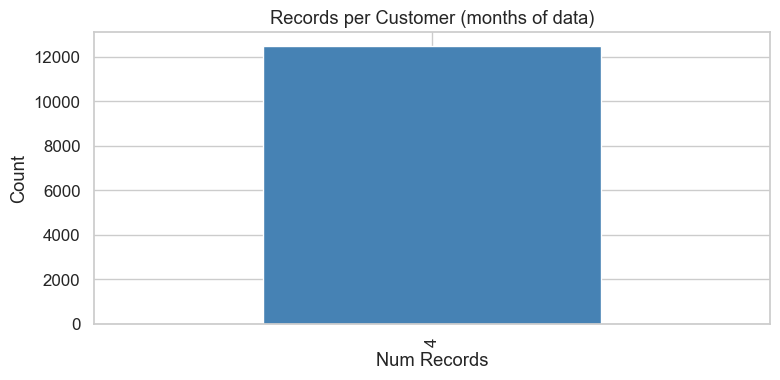

In [3]:
# ── 2. Records per customer distribution ──
rpc = df_raw.groupby('Customer_ID').size()
print(rpc.describe())

fig, ax = plt.subplots(figsize=(8, 4))
rpc.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Records per Customer (months of data)')
ax.set_xlabel('Num Records'); ax.set_ylabel('Count')
plt.tight_layout()
# os.makedirs('models', exist_ok=True)
plt.savefig(os.path.join(save_dir, 'plot_records_per_customer.png'), dpi=150)
plt.show()

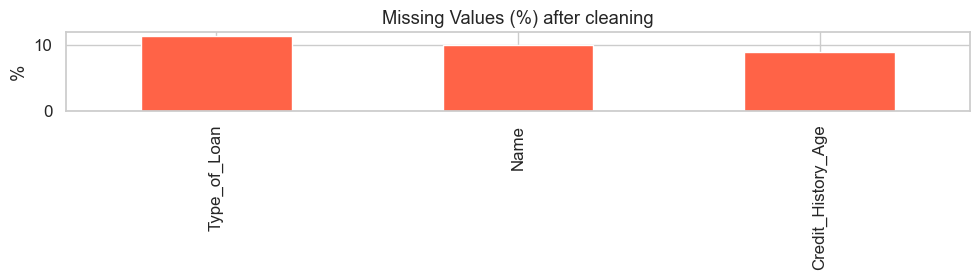

In [4]:
# ── 3. Missing value heatmap ──
missing_pct = df_raw.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
if not missing_pct.empty:
    fig, ax = plt.subplots(figsize=(10, 3))
    missing_pct.plot(kind='bar', ax=ax, color='tomato')
    ax.set_title('Missing Values (%) after cleaning')
    ax.set_ylabel('%')
    plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_missing_values.png'), dpi=150)
    plt.show()
else:
    print('No missing values after cleaning ✓')

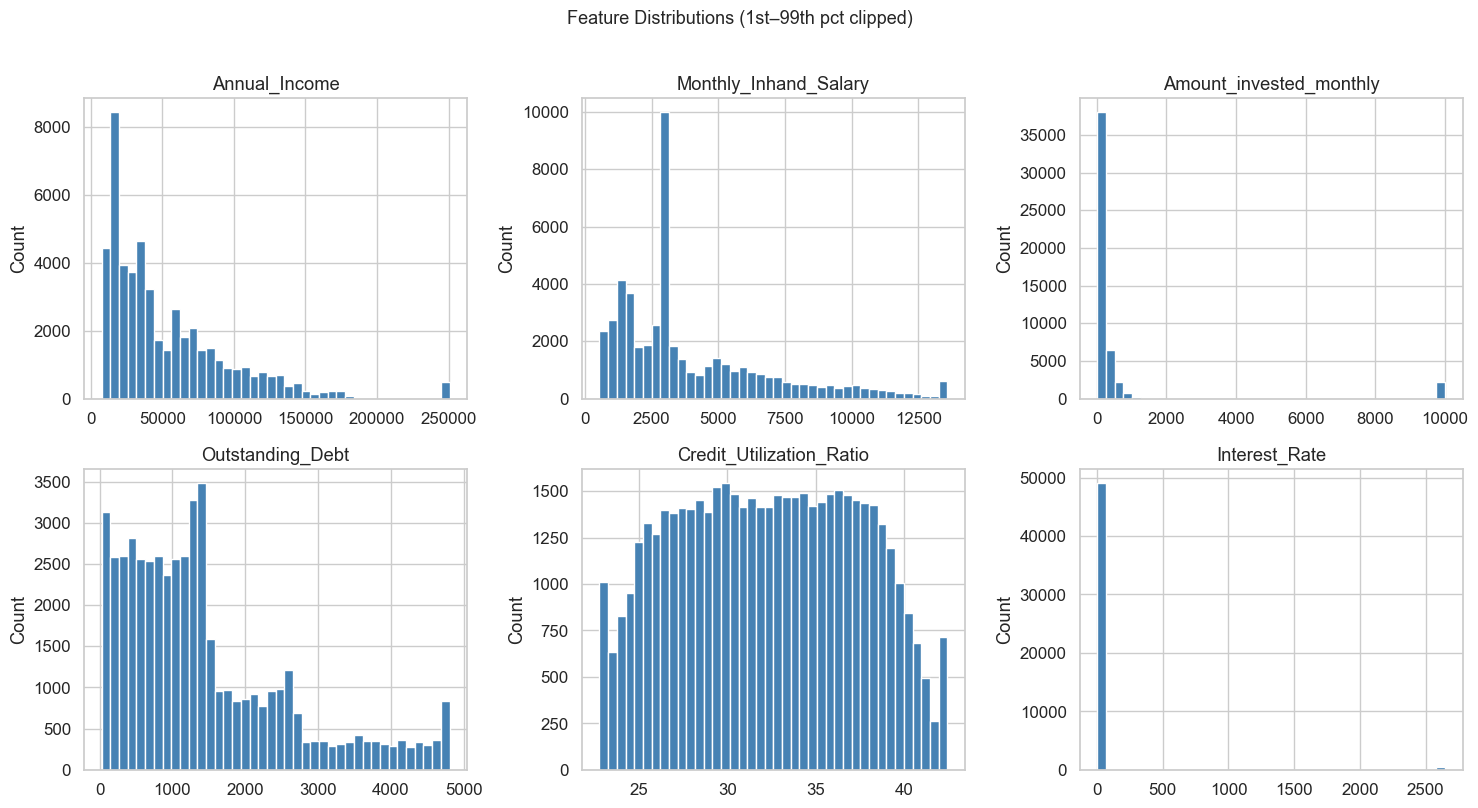

In [5]:
# ── 4. Key feature distributions ──
num_cols = ['Annual_Income', 'Monthly_Inhand_Salary',
            'Amount_invested_monthly', 'Outstanding_Debt',
            'Credit_Utilization_Ratio', 'Interest_Rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    if col in df_raw.columns:
        df_raw[col].dropna().clip(
            df_raw[col].quantile(0.01), df_raw[col].quantile(0.99)
        ).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(col); ax.set_ylabel('Count')
plt.suptitle('Feature Distributions (1st–99th pct clipped)', fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_feature_distributions.png'), dpi=150)
plt.show()

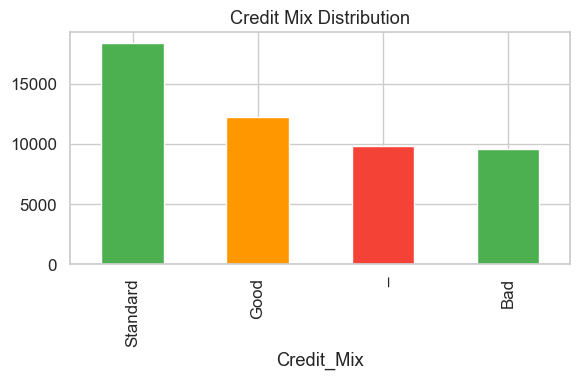

In [6]:
# ── 5. Credit Mix distribution ──
fig, ax = plt.subplots(figsize=(6, 4))
if 'Credit_Mix' in df_raw.columns:
    df_raw['Credit_Mix'].str.strip().value_counts().plot(
        kind='bar', ax=ax, color=['#4CAF50','#FF9800','#F44336'], edgecolor='white'
    )
ax.set_title('Credit Mix Distribution')
plt.tight_layout(); plt.show()

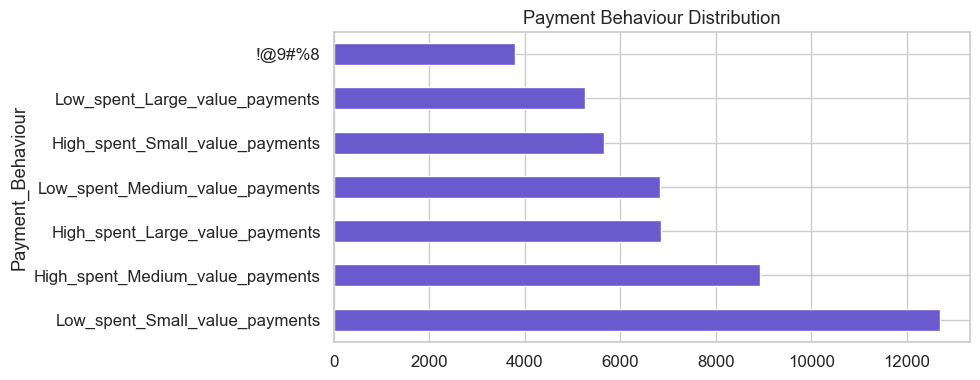

In [7]:
# ── 6. Payment Behaviour distribution ──
fig, ax = plt.subplots(figsize=(10, 4))
if 'Payment_Behaviour' in df_raw.columns:
    df_raw['Payment_Behaviour'].str.strip().value_counts().plot(
        kind='barh', ax=ax, color='slateblue', edgecolor='white'
    )
ax.set_title('Payment Behaviour Distribution')
plt.tight_layout(); plt.show()

In [8]:
# ── 7. Per-customer feature engineering + risk labelling ──
from src.preprocessing import aggregate_per_customer, engineer_features
from src.risk_labeling  import assign_risk_label, FEATURE_WEIGHTS

df_agg  = aggregate_per_customer(df_raw)
df_feat = engineer_features(df_agg, fit_scaler=True)
df_lab  = assign_risk_label(df_feat, fit_encoder=True)

print(f'Per-customer records: {len(df_lab)}')
print(df_lab['risk_label'].value_counts())

Per-customer records: 12500
risk_label
High         3125
Low          3125
Medium       3124
Very_High    1563
Very_Low     1563
Name: count, dtype: int64


In [ ]:
# ── 7a. Inspect the 3 new features (v2) ──
new_feats = ['EMI_Income_Ratio', 'Savings_Rate', 'Credit_History_Score']
print("=== New Derived Features (v2) ===")
for feat in new_feats:
    if feat in df_lab.columns:
        vals = df_lab[feat]
        print(f"  {feat:25s}  min={vals.min():.4f}  mean={vals.mean():.4f}  max={vals.max():.4f}")
    else:
        print(f"  {feat:25s}  NOT FOUND in df_lab")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, new_feats):
    if feat in df_lab.columns:
        df_lab[feat].hist(bins=50, ax=ax, color='teal', edgecolor='white', alpha=0.8)
        ax.set_title(feat)
        ax.set_ylabel('Count')
plt.suptitle('New Derived Features (v2)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'plot_new_features_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAll {len(new_feats)} new features present and non-null")

---
## Raw Risk Score Distribution — Before Bell-Curve Binning

The composite score `Σ(weight × feature)` is a continuous number.  
**Bell-curve `pd.qcut` bins** are applied using `RISK_QUANTILES = [0.0, 0.125, 0.375, 0.625, 0.875, 1.0]`, giving:

| Class | Quantile Range | Target % |
|-------|---------------|----------|
| Very_Low | 0% – 12.5% | **12.5%** |
| Low | 12.5% – 37.5% | **25.0%** |
| Medium | 37.5% – 62.5% | **25.0%** |
| High | 62.5% – 87.5% | **25.0%** |
| Very_High | 87.5% – 100% | **12.5%** |

The plots below show the raw score shape and the final label distribution after binning.


Raw risk score range: -1.9595 to 8.1958
=== Raw Risk Score Statistics (before bell-curve qcut) ===
count    12500.0000
mean         3.6731
std          1.5274
min         -1.9595
25%          2.6661
50%          3.6972
75%          4.7192
max          8.1958

Bell-curve qcut boundaries (RISK_QUANTILES=[0.0, 0.125, 0.375, 0.625, 0.875, 1.0]): [-1.96, 1.89, 3.213, 4.177, 5.447, 8.196]

Customers per bin after bell-curve qcut:
  Very_Low    :  1563  (12.5%)
  Low         :  3125  (25.0%)
  Medium      :  3124  (25.0%)
  High        :  3125  (25.0%)
  Very_High   :  1563  (12.5%)

Actual label counts in df_lab (from assign_risk_label, should match above):
  Very_Low    :  1563  (12.5%) ✓
  Low         :  3125  (25.0%) ✓
  Medium      :  3124  (25.0%) ✓
  High        :  3125  (25.0%) ✓
  Very_High   :  1563  (12.5%) ✓


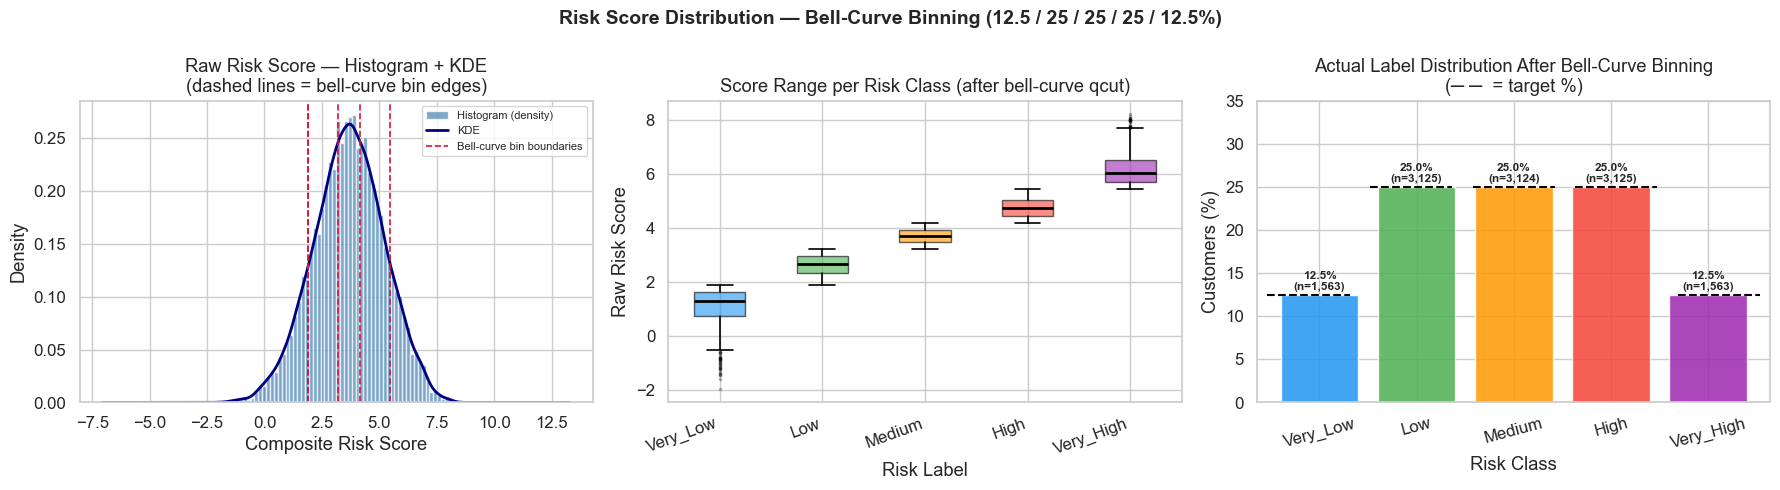


✓ Bell-curve binning confirmed: Very_Low≈12.5%, Low≈25%, Medium≈25%, High≈25%, Very_High≈12.5%
  RISK_QUANTILES used: [0.0, 0.125, 0.375, 0.625, 0.875, 1.0]


In [9]:
# ── 7b. Raw risk score distribution — before bell-curve qcut ──────────────────
from src.risk_labeling import compute_risk_score, FEATURE_WEIGHTS, RISK_QUANTILES
from config import RISK_CLASSES

# Compute raw scores on the per-customer feature-engineered data
raw_scores = compute_risk_score(df_feat)

print(f"Raw risk score range: {raw_scores.min():.4f} to {raw_scores.max():.4f}")

# Compute the BELL-CURVE boundaries (RISK_QUANTILES = [0.0, 0.125, 0.375, 0.625, 0.875, 1.0])
quintile_edges = pd.qcut(raw_scores, q=RISK_QUANTILES, retbins=True)[1]

print("=== Raw Risk Score Statistics (before bell-curve qcut) ===")
print(raw_scores.describe().round(4).to_string())
print(f"\nBell-curve qcut boundaries (RISK_QUANTILES={RISK_QUANTILES}): {[round(b, 3) for b in quintile_edges]}")
print(f"\nCustomers per bin after bell-curve qcut:")
binned = pd.qcut(raw_scores, q=RISK_QUANTILES, labels=RISK_CLASSES)
counts_binned = binned.value_counts().reindex(RISK_CLASSES)
total = len(raw_scores)
for cls, cnt in counts_binned.items():
    pct = 100 * cnt / total
    print(f"  {cls:<12}: {cnt:5d}  ({pct:.1f}%)")

# Also check df_lab (actual labels from assign_risk_label)
print(f"\nActual label counts in df_lab (from assign_risk_label, should match above):")
actual_counts = df_lab['risk_label'].value_counts().reindex(RISK_CLASSES)
for cls, cnt in actual_counts.items():
    pct = 100 * cnt / len(df_lab)
    print(f"  {cls:<12}: {cnt:5d}  ({pct:.1f}%) {'✓' if abs(pct - ([12.5,25,25,25,12.5][RISK_CLASSES.index(cls)])) < 1 else '✗'}")

PALETTE = {'Very_Low': '#2196F3', 'Low': '#4CAF50',
           'Medium': '#FF9800', 'High': '#F44336', 'Very_High': '#9C27B0'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Risk Score Distribution — Bell-Curve Binning (12.5 / 25 / 25 / 25 / 12.5%)",
             fontsize=14, fontweight='bold')

# ── Plot 1: Raw histogram + KDE with bell-curve boundaries ────────────────────
ax = axes[0]
ax.hist(raw_scores, bins=60, color='steelblue', alpha=0.7, edgecolor='white',
        density=True, label='Histogram (density)')
raw_scores.plot(kind='kde', ax=ax, color='navy', linewidth=2, label='KDE')
for edge in quintile_edges[1:-1]:
    ax.axvline(edge, color='crimson', linestyle='--', linewidth=1.2)
ax.axvline(quintile_edges[1], color='crimson', linestyle='--', linewidth=1.2,
           label='Bell-curve bin boundaries')
ax.set_title("Raw Risk Score — Histogram + KDE\n(dashed lines = bell-curve bin edges)")
ax.set_xlabel("Composite Risk Score")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

# ── Plot 2: Boxplot of per-class score ranges ─────────────────────────────────
ax = axes[1]
score_df = pd.DataFrame({'risk_score': raw_scores.values,
                          'risk_label': df_lab['risk_label'].values})
for i, label in enumerate(RISK_CLASSES):
    subset = score_df[score_df['risk_label'] == label]['risk_score']
    ax.boxplot(subset, positions=[i], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=PALETTE[label], alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1.2),
               capprops=dict(linewidth=1.2),
               flierprops=dict(marker='.', alpha=0.3, markersize=3))
ax.set_xticks(range(len(RISK_CLASSES)))
ax.set_xticklabels(RISK_CLASSES, rotation=20, ha='right')
ax.set_title("Score Range per Risk Class (after bell-curve qcut)")
ax.set_xlabel("Risk Label")
ax.set_ylabel("Raw Risk Score")

# ── Plot 3: Actual label distribution bar chart (bell-curve result) ───────────
ax = axes[2]
TARGET_PCT = {'Very_Low': 12.5, 'Low': 25.0, 'Medium': 25.0, 'High': 25.0, 'Very_High': 12.5}
bars = ax.bar(RISK_CLASSES,
              [100 * actual_counts[c] / len(df_lab) for c in RISK_CLASSES],
              color=[PALETTE[c] for c in RISK_CLASSES],
              edgecolor='white', alpha=0.85)
# Target line overlay
for i, cls in enumerate(RISK_CLASSES):
    ax.axhline(TARGET_PCT[cls], xmin=(i + 0.1) / len(RISK_CLASSES),
               xmax=(i + 0.9) / len(RISK_CLASSES),
               color='black', linestyle='--', linewidth=1.5)
# Value labels on bars
for bar, cls in zip(bars, RISK_CLASSES):
    pct = 100 * actual_counts[cls] / len(df_lab)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{pct:.1f}%\n(n={actual_counts[cls]:,})',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title("Actual Label Distribution After Bell-Curve Binning\n(─ ─  = target %)")
ax.set_xlabel("Risk Class")
ax.set_ylabel("Customers (%)")
ax.set_ylim(0, 35)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()

# Save
import os
save_dir = os.path.join(os.path.abspath('..'), 'models')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'plot_raw_risk_score_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Bell-curve binning confirmed: Very_Low≈12.5%, Low≈25%, Medium≈25%, High≈25%, Very_High≈12.5%")
print(f"  RISK_QUANTILES used: {RISK_QUANTILES}")


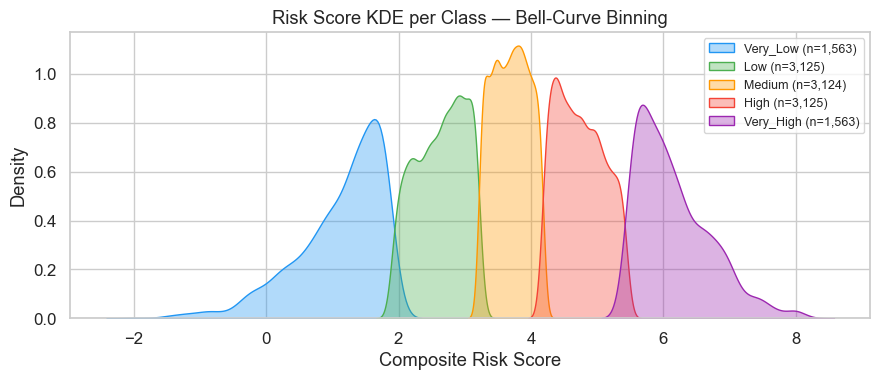

In [10]:
# ── KDE overlay: raw score for each risk class (bell-curve shape confirmed) ───
fig, ax = plt.subplots(figsize=(9, 4))
for cls in RISK_CLASSES:
    subset_scores = score_df[score_df['risk_label'] == cls]['risk_score']
    sns.kdeplot(subset_scores, fill=True, alpha=0.35, color=PALETTE[cls],
                label=f"{cls} (n={len(subset_scores):,})", ax=ax)
ax.set_title("Risk Score KDE per Class — Bell-Curve Binning")
ax.set_xlabel("Composite Risk Score")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'plot_raw_risk_score_distribution1.png'), dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ── 8. Risk label distribution ──
from src.utils import plot_risk_distribution

plot_risk_distribution(
    df_lab['risk_label'].values,
    title='Risk Appetite Distribution — All Customers (5 Classes)',
    save_path=os.path.join(save_dir, 'plot_risk_distribution.png')
)

Saved distribution plot → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_risk_distribution.png


In [12]:
# ── 9. Feature importance (domain weights) ──
from src.utils import plot_feature_importance

plot_feature_importance(
    FEATURE_WEIGHTS,
    save_path=os.path.join(save_dir, 'plot_feature_importance.png')
)

Saved feature importance plot → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_feature_importance.png


In [13]:
# ── 10. Correlation heatmap of engineered features ──
from config import RISK_FEATURES

feat_available = [f for f in RISK_FEATURES if f in df_lab.columns]
corr = df_lab[feat_available].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_feature_correlation.png'), dpi=150)
plt.show()

In [14]:
# ── 11. Mutual Fund EDA ──
from src.recommender import load_mutual_funds

mf_df = load_mutual_funds()
print(f'Mutual Fund catalogue: {len(mf_df)} funds, {mf_df["AMC"].nunique()} AMCs')

print('\nRisk Tier Assignment:')
print(mf_df['risk_tier'].value_counts(dropna=False))

Mutual Fund catalogue: 14270 funds, 51 AMCs

Risk Tier Assignment:
risk_tier
None         7343
Very_High    2804
Very_Low     1591
Low           975
Medium        803
High          754
Name: count, dtype: int64


In [15]:
# ── 12. Mutual fund risk tier distribution ──
mf_tier = mf_df['risk_tier'].dropna().value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
mf_tier.plot(kind='bar', ax=ax,
             color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0'],
             edgecolor='white')
ax.set_title('Mutual Fund Count by Risk Tier')
ax.set_xlabel('Risk Tier'); ax.set_ylabel('Number of Funds')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_mf_risk_tiers.png'), dpi=150)
plt.show()

In [16]:
# ── 13. AUM distribution by risk tier ──
fig, ax = plt.subplots(figsize=(10, 5))
mf_df_plot = mf_df.dropna(subset=['risk_tier', 'Average_AUM_Cr'])
mf_df_plot['Average_AUM_Cr_log'] = np.log1p(mf_df_plot['Average_AUM_Cr'])
sns.boxplot(data=mf_df_plot, x='risk_tier', y='Average_AUM_Cr_log', ax=ax, palette='muted')
ax.set_title('log(AUM+1) by Risk Tier')
ax.set_xlabel('Risk Tier'); ax.set_ylabel('log1p(AUM Cr)')
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_aum_by_tier.png'), dpi=150)
plt.show()

In [17]:
# ── 14. Investment ratio vs risk label ──
fig, ax = plt.subplots(figsize=(9, 4))
for label in df_lab['risk_label'].unique():
    ax.hist(
        df_lab[df_lab['risk_label'] == label]['Investment_Ratio'].clip(0, 2),
        bins=30, alpha=0.5, label=label, density=True
    )
ax.set_title('Investment Ratio Distribution by Risk Label')
ax.set_xlabel('Investment Ratio (capped at 2)')
ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_inv_ratio_by_risk.png'), dpi=150)
plt.show()

In [18]:
# ── 15. NAV History — quick stats and reference date ──
from src.nav_history import nav_history_quick_stats, load_nav_metrics, _ref_date
from config import NAV_HISTORY_PARQUET

import os
if not NAV_HISTORY_PARQUET.exists():
    print(f"Parquet not found at: {NAV_HISTORY_PARQUET}")
else:
    stats = nav_history_quick_stats()
    ref   = _ref_date()

    print("─── NAV History Parquet — Quick Stats ───")
    print(f"  File            : {NAV_HISTORY_PARQUET.name}")
    print(f"  Total rows      : {stats['total_rows']:>12,}")
    print(f"  Schemes (sample): {stats['sample_schemes']:>12,}")
    print(f"  Date range      : {stats['sample_date_min'].date()} → {stats['sample_date_max'].date()}")
    print(f"  Reference date  : {ref.date()}  ← latest NAV date in parquet")
    print(f"  Row groups      : {stats['num_row_groups']}")
    print()

    nav_metrics = load_nav_metrics(verbose=True)
    print()
    print("─── NAV Metrics Cache — Summary ─────────")
    print(nav_metrics[['cagr_1yr','cagr_3yr','cagr_5yr',
                        'sharpe_1yr','max_drawdown','record_count']].describe().round(4))


─── NAV History Parquet — Quick Stats ───
  File            : mutual_fund_nav_history.parquet
  Total rows      :   21,357,943
  Schemes (sample):          222
  Date range      : 2006-04-01 → 2026-02-15
  Reference date  : 2026-02-15  ← latest NAV date in parquet
  Row groups      : 21

[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,427 scheme metrics from cache.

─── NAV Metrics Cache — Summary ─────────
         cagr_1yr    cagr_3yr    cagr_5yr  sharpe_1yr  max_drawdown  \
count  13616.0000  12062.0000  10263.0000   7889.0000     9082.0000   
mean       0.0606      0.0543      0.0389     -0.6208       -0.0996   
std        0.1413      0.0830      0.0746      2.7133        0.1056   
min       -0.8254     -0.5181     -0.6019    -10.0000       -0.9297   
25%        0.0000      0.0000      0.0000     -0.7669       -0.1844   
50%        0.0010      0.0004      0.0026      0.2480       -0.0617   


---
## Summary
- **50 000 raw records** → **12 500 unique customers** (after per-customer aggregation).
- After aggregation + feature engineering: **15 features** per customer (v2: added EMI_Income_Ratio, Savings_Rate, Credit_History_Score).
- Risk labels derived via composite scoring → **bell-curve 5-class bins** using `RISK_QUANTILES = [0.0, 0.125, 0.375, 0.625, 0.875, 1.0]`:
  - Very_Low: **12.5%** (1 563 customers), Low: **25%** (3 125), Medium: **25%** (3 124), High: **25%** (3 125), Very_High: **12.5%** (1 563)
- **14 270 mutual funds** tagged with risk tier via `Scheme_Category` keyword mapping.

→ Proceed to **Notebook 02** for central model training.